In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
df=pd.read_csv(r"C:\Users\dawes\OneDrive\Desktop\HR_Attrition_Project\data\WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)

(1470, 35)


In [3]:
df = df.drop(['EmployeeCount', 'EmployeeNumber', 
              'Over18', 'StandardHours'], axis=1)
print("✅ Useless columns dropped!")
print(df.shape)

✅ Useless columns dropped!
(1470, 31)


In [4]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
print("✅ Encoding done!")
df.head()

✅ Encoding done!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [5]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 30)
y shape: (1470,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)

Train size: (1176, 30)
Test  size: (294, 30)


In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [8]:
y_pred = model.predict(X_test)
print("✅ Predictions done!")

✅ Predictions done!


In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {round(accuracy*100, 2)}%")

Model Accuracy: 88.1%


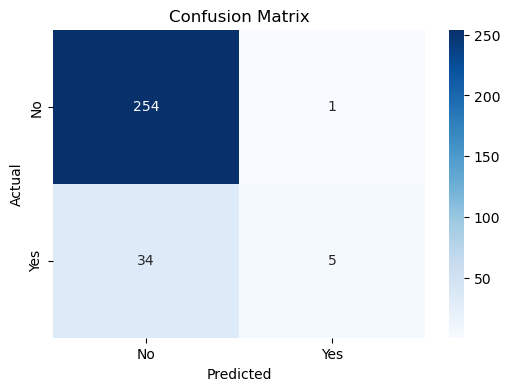

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'],
            yticklabels=['No','Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../outputs/09_confusion_matrix.png')
plt.show()

In [11]:
print(classification_report(y_test, y_pred, 
      target_names=['No','Yes']))

              precision    recall  f1-score   support

          No       0.88      1.00      0.94       255
         Yes       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



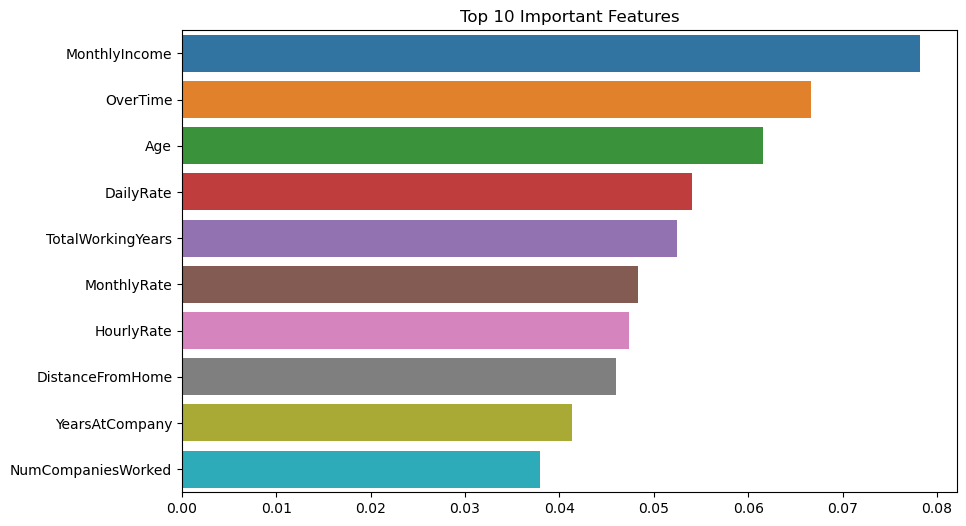

In [12]:
feat_imp = pd.Series(model.feature_importances_, 
                     index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 10 Important Features')
plt.savefig('../outputs/10_feature_importance.png')
plt.show()